In [ ]:
import pandas as pd

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Read the CSV file
df = pd.read_csv("student_performance_synthetic.csv")
# Display the first 10 rows
df.head(10)

Saving student_performance_synthetic.csv to student_performance_synthetic.csv


,Student_ID,Study_Time_Hours,Attendance_Percent,Previous_Marks,Final_Marks
0,S001,4,91,67,55
1,S002,5,95,70,51
2,S003,3,91,55,50
3,S004,5,94,83,71
4,S005,5,86,84,66
5,S006,2,77,58,50
6,S007,3,72,74,45
7,S008,3,93,79,66
8,S009,3,83,70,47
9,S010,5,85,80,56


In [ ]:
# Basic information about the dataset
print("Number of students:", len(df))
print("\nDataset information:")
print(df.info())

print("\nSummary statistics:")
display(df.describe())

Number of students: 100

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Student_ID          100 non-null    object
 1   Study_Time_Hours    100 non-null    int64 
 2   Attendance_Percent  100 non-null    int64 
 3   Previous_Marks      100 non-null    int64 
 4   Final_Marks         100 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 4.0+ KB
None

Summary statistics:


,Study_Time_Hours,Attendance_Percent,Previous_Marks,Final_Marks
count,100.000000,100.000000,100.000000,100.000000
mean,3.690000,85.910000,70.980000,54.840000
std,1.624901,8.343745,8.965681,9.289638
min,1.000000,61.000000,50.000000,35.000000
25%,2.000000,79.750000,64.750000,48.000000
50%,4.000000,85.000000,70.500000,54.000000
75%,5.000000,93.000000,77.250000,62.250000
max,6.000000,100.000000,93.000000,74.000000


In [ ]:
# Correlation between study time and final marks

correlation = df["Study_Time_Hours"].corr(df["Final_Marks"])

print("Correlation between Study Time and Final Marks:", round(correlation, 3))

Correlation between Study Time and Final Marks: 0.723


In [ ]:
from scipy.stats import pearsonr

# Pearson correlation test
r, p_value = pearsonr(
    df["Study_Time_Hours"],
    df["Final_Marks"]
)

print("Correlation (r):", round(r, 3))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: The relationship is statistically significant.")
else:
    print("Result: The relationship is not statistically significant.")

Correlation (r): 0.723
P-value: 0.0
Result: The relationship is statistically significant.


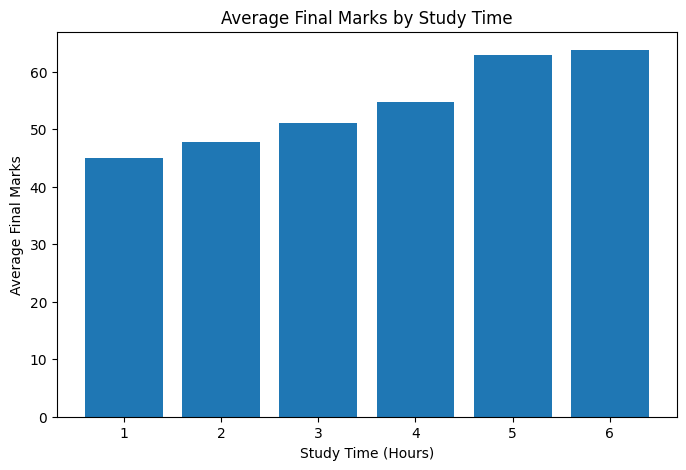

In [ ]:
import matplotlib.pyplot as plt

average_marks = df.groupby("Study_Time_Hours")["Final_Marks"].mean()

plt.figure(figsize=(8, 5))
plt.bar(average_marks.index, average_marks.values)
plt.xlabel("Study Time (Hours)")
plt.ylabel("Average Final Marks")
plt.title("Average Final Marks by Study Time")
plt.xticks(average_marks.index)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[["Study_Time_Hours"]]
y = df["Final_Marks"]

model = LinearRegression()
model.fit(X, y)

print("Regression Coefficient:", round(model.coef_[0], 3))
print("Intercept:", round(model.intercept_, 3))
print("R-squared:", round(model.score(X, y), 3))

Regression Coefficient: 4.136
Intercept: 39.579
R-squared: 0.523


In [ ]:
# Final Analysis Summary

print("=== Student Performance Analysis ===")
print("Dataset: Synthetic student performance data")
print("Number of students:", len(df))

print("\nResearch Question:")
print("Does study time have a significant relationship with students' academic performance?")

print("\nStatistical Results:")
print("Pearson correlation (r):", round(r, 3))
print("P-value:", "< 0.001" if p_value < 0.001 else round(p_value, 4))

print("\nRegression Results:")
print("Coefficient:", round(model.coef_[0], 3))
print("Intercept:", round(model.intercept_, 3))
print("R-squared:", round(model.score(X, y), 3))

print("\nConclusion:")
print("Study time showed a statistically significant positive relationship")
print("with final marks in this synthetic dataset.")

=== Student Performance Analysis ===
Dataset: Synthetic student performance data
Number of students: 100

Research Question:
Does study time have a significant relationship with students' academic performance?

Statistical Results:
Pearson correlation (r): 0.723
P-value: < 0.001

Regression Results:
Coefficient: 4.136
Intercept: 39.579
R-squared: 0.523

Conclusion:
Study time showed a statistically significant positive relationship
with final marks in this synthetic dataset.
